# Crossmatch: DJA spectra × JWST F150W cutouts

Match `DJA_spectra_v4.5.fits` against the F150W image store
(`f150w_*.h5` COSMOS tiles + `ceers_f150w.h5`) by sky position.

**Output** `dja_matched.h5` — image-store layout for matched objects:
- `image` 128×128 cutout
- `id`    — **row index into the DJA file** (`dja[col][id]` → spectrum / `z_best` / …)
- `ra`, `dec`, `sep_arcsec`

In [1]:
import h5py
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

DJA_file  = Path('/home/yacheng/ssl_outthere/data/spectrum/DJA_spectra_v4.5.fits')
IMG_DIR = Path('/home/yacheng/ssl_outthere/images/jwst/f150w')   # new image store (cosmos tiles + ceers)
OUT_DIR = Path('/home/yacheng/ssl_outthere/data/survey/dja_crossmatch')
OUT_DIR.mkdir(parents=True, exist_ok=True)

MAX_SEP_ARCSEC = 0.5

## 1. Load DJA spectra (all columns)

In [2]:
from astropy.table import Table
dja = Table.read(DJA_file)
dja_keys = list(dja.keys())

dja['ra']  = dja['ra'].astype(np.float64)
dja['dec'] = dja['dec'].astype(np.float64)
n_dja = len(dja['ra'])

print(f'DJA spectra : {n_dja:,}')
print(f'keys        : {dja_keys}')
print(f'RA  range   : {dja["ra"].min():.2f} – {dja["ra"].max():.2f} deg')
print(f'Dec range   : {dja["dec"].min():.2f} – {dja["dec"].max():.2f} deg')

DJA spectra : 42,196
keys        : ['file', 'srcid', 'ra', 'dec', 'grating', 'filter', 'effexptm', 'nfiles', 'dataset', 'msamet', 'msaid', 'msacnf', 'dithn', 'slitid', 'root', 'npix', 'ndet', 'wmin', 'wmax', 'wmaxsn', 'sn10', 'flux10', 'err10', 'sn50', 'flux50', 'err50', 'sn90', 'flux90', 'err90', 'xstart', 'ystart', 'xsize', 'ysize', 'slit_pa', 'pa_v3', 'srcypix', 'profcen', 'profsig', 'ctime', 'version', 'exptime', 'contchi2', 'dof', 'fullchi2', 'line_ariii_7138', 'line_ariii_7138_err', 'line_ariii_7753', 'line_ariii_7753_err', 'line_bra', 'line_bra_err', 'line_brb', 'line_brb_err', 'line_brd', 'line_brd_err', 'line_brg', 'line_brg_err', 'line_hb', 'line_hb_err', 'line_hd', 'line_hd_err', 'line_hei_1083', 'line_hei_1083_err', 'line_hei_3889', 'line_hei_3889_err', 'line_hei_5877', 'line_hei_5877_err', 'line_hei_7065', 'line_hei_7065_err', 'line_hei_8446', 'line_hei_8446_err', 'line_heii_4687', 'line_heii_4687_err', 'line_hg', 'line_hg_err', 'line_lya', 'line_lya_err', 'line_mgii', 'li

## 2. Build position index from all f150w cutout h5 files

In [3]:
img_files = sorted(IMG_DIR.glob('f150w*.h5'))
print(f'Found {len(img_files)} image h5 files')

all_ra, all_dec     = [], []
all_file_idx        = []
all_local_idx       = []
img_keys            = None

for fi, path in enumerate(img_files):
    with h5py.File(path, 'r') as f:
        ra  = f['ra'][:].astype(np.float64)
        dec = f['dec'][:].astype(np.float64)
        n   = len(ra)
        if img_keys is None:
            img_keys = list(f.keys())
    all_ra.append(ra)
    all_dec.append(dec)
    all_file_idx.append(np.full(n, fi, dtype=np.int32))
    all_local_idx.append(np.arange(n, dtype=np.int32))
    print(f'  {path.name}: {n:,}')

all_ra        = np.concatenate(all_ra)
all_dec       = np.concatenate(all_dec)
all_file_idx  = np.concatenate(all_file_idx)
all_local_idx = np.concatenate(all_local_idx)

print(f'\nTotal image catalog : {len(all_ra):,} objects')
print(f'Image h5 keys       : {img_keys}')

Found 20 image h5 files
  f150w_A1.h5: 31,359
  f150w_A10.h5: 29,617
  f150w_A2.h5: 33,022
  f150w_A3.h5: 32,996
  f150w_A4.h5: 32,220
  f150w_A5.h5: 26,141
  f150w_A6.h5: 33,155
  f150w_A7.h5: 33,920
  f150w_A8.h5: 32,117
  f150w_A9.h5: 31,424
  f150w_B1.h5: 31,224
  f150w_B10.h5: 28,646
  f150w_B2.h5: 31,936
  f150w_B3.h5: 31,758
  f150w_B4.h5: 34,151
  f150w_B5.h5: 27,478
  f150w_B6.h5: 34,316
  f150w_B7.h5: 35,690
  f150w_B8.h5: 35,341
  f150w_B9.h5: 34,639

Total image catalog : 641,150 objects
Image h5 keys       : ['dec', 'id', 'image', 'ra', 'seg']


## 3. Crossmatch DJA ↔ image catalog

In [4]:
dja_coords = SkyCoord(ra=dja['ra'] * u.deg, dec=dja['dec'] * u.deg)
img_coords = SkyCoord(ra=all_ra    * u.deg, dec=all_dec    * u.deg)

# Match direction: image → spectrum (each image finds its nearest spectrum).
# This guarantees every matched IMAGE is unique — no cutout is reused.
idx_dja_all, sep, _ = img_coords.match_to_catalog_sky(dja_coords)
sep_arcsec_img      = sep.to(u.arcsec).value          # length = N_img

mask_img = sep_arcsec_img <= MAX_SEP_ARCSEC           # images with a spectrum within the cut
img_sel  = np.where(mask_img)[0]                      # global image indices (already unique)
dja_sel  = idx_dja_all[img_sel]                       # nearest spectrum row for each such image
sep_sel  = sep_arcsec_img[img_sel]

# A single spectrum can still be the nearest neighbour of >1 image. Enforce a
# strict 1:1 match by keeping, per spectrum, only the closest image → no
# duplicate spectra either. (Closest-first greedy over the matched subset.)
order = np.argsort(sep_sel)                           # closest first
seen, keep = set(), []
for k in order:
    s = int(dja_sel[k])
    if s in seen:
        continue
    seen.add(s)
    keep.append(k)
keep = np.sort(np.asarray(keep, dtype=np.int64))

img_glob_idx = img_sel[keep]                          # unique image global indices
dja_idx      = dja_sel[keep]                          # unique DJA spectrum rows
sep_matched  = sep_sel[keep]
n_match      = len(keep)

assert len(np.unique(img_glob_idx)) == n_match, 'image duplicates remain'
assert len(np.unique(dja_idx))      == n_match, 'spectrum duplicates remain'

print(f'Images with a spectrum ≤ {MAX_SEP_ARCSEC}\": {mask_img.sum():,} / {len(all_ra):,}')
print(f'Dropped as duplicate-spectrum (kept closest): {mask_img.sum() - n_match:,}')
print(f'Final 1:1 pairs (unique image & spectrum)    : {n_match:,}')
print(f'Median sep (matched)                         : {np.median(sep_matched):.3f} arcsec')

Images with a spectrum ≤ 0.5": 2,746 / 641,150
Dropped as duplicate-spectrum (kept closest): 80
Final 1:1 pairs (unique image & spectrum)    : 2,666
Median sep (matched)                         : 0.027 arcsec


## 4. Separation distribution

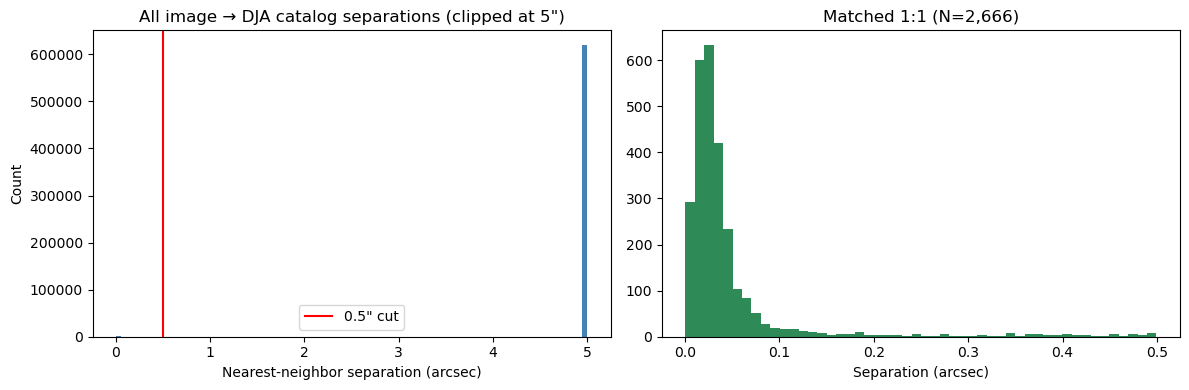

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(np.clip(sep_arcsec_img, 0, 5), bins=100, color='steelblue', edgecolor='none')
ax.axvline(MAX_SEP_ARCSEC, color='red', lw=1.5, label=f'{MAX_SEP_ARCSEC}" cut')
ax.set_xlabel('Nearest-neighbor separation (arcsec)')
ax.set_ylabel('Count')
ax.set_title('All image → DJA catalog separations (clipped at 5")')
ax.legend()

ax = axes[1]
ax.hist(sep_matched, bins=50, color='seagreen', edgecolor='none')
ax.set_xlabel('Separation (arcsec)')
ax.set_title(f'Matched 1:1 (N={n_match:,})')

plt.tight_layout()
plt.savefig(OUT_DIR / 'separation_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Matched sample overview

In [6]:
# img_glob_idx / dja_idx / sep_matched come from the 1:1 match above.
matched_file_idx  = all_file_idx[img_glob_idx]
matched_local_idx = all_local_idx[img_glob_idx]

z  = dja['z_best'][dja_idx]
sn = dja['sn50'][dja_idx]
print(f'Matched pairs : {n_match:,}')
print(f'z_best : median={np.nanmedian(z):.2f}, range=[{np.nanmin(z):.2f}, {np.nanmax(z):.2f}]')
print(f'sn50   : median={np.nanmedian(sn):.1f}, range=[{np.nanmin(sn):.1f}, {np.nanmax(sn):.1f}]')

unique_files = np.unique(matched_file_idx)
print(f'\nFiles with matches:')
for fi in unique_files:
    cnt = (matched_file_idx == fi).sum()
    print(f'  {img_files[fi].name}: {cnt:,}')

Matched pairs : 2,666
z_best : median=1.80, range=[-1.00, 9.81]
sn50   : median=2.8, range=[-8.2, 407.9]

Files with matches:
  f150w_A2.h5: 2
  f150w_A3.h5: 198
  f150w_B2.h5: 171
  f150w_B3.h5: 252
  f150w_B7.h5: 565
  f150w_B8.h5: 1,478


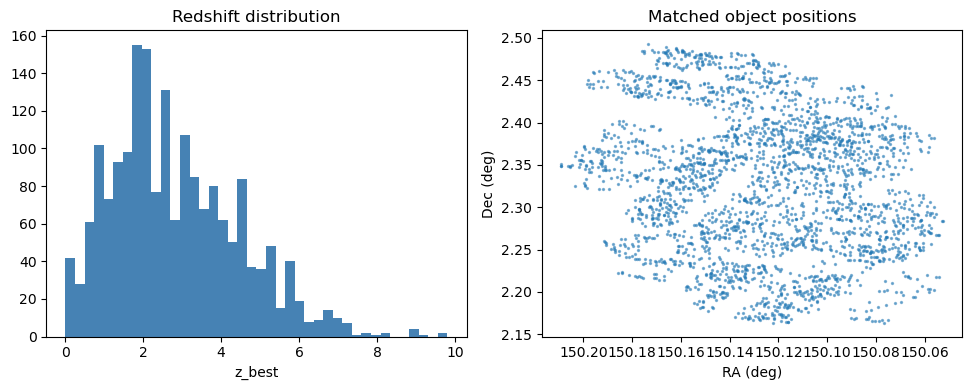

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(z[np.isfinite(z) & (z >= 0)], bins=40, color='steelblue', edgecolor='none')
axes[0].set_xlabel('z_best')
axes[0].set_title('Redshift distribution')

axes[1].scatter(all_ra[img_glob_idx], all_dec[img_glob_idx],
                s=2, alpha=0.5, rasterized=True)
axes[1].set_xlabel('RA (deg)')
axes[1].set_ylabel('Dec (deg)')
axes[1].set_title('Matched object positions')
axes[1].invert_xaxis()

plt.tight_layout()
plt.savefig(OUT_DIR / 'matched_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Save matched cutouts (image-store layout, `id` → DJA file)

Write `dja_matched.h5` with the **same datasets as the image store** — `image`, `id`, `ra`, `dec` (+ `sep_arcsec`) — except `id` is the **row index into the DJA file**. Downstream: load the cutout from this file and its spectrum/redshift from `DJA_spectra_v4.5.fits` via `dja[col][id]`. (No `seg`: the new store / CEERS don't carry it.)

In [8]:
out_path = OUT_DIR / 'dja_matched.h5'

# Probe the cutout shape/dtype from the first image-store file.
with h5py.File(img_files[0], 'r') as f0:
    img_shape = f0['image'].shape[1:]   # (128, 128)
    img_dtype = f0['image'].dtype

print(f'image cutout : {img_shape}  {img_dtype}')
print(f'output       : {out_path}')

image cutout : (128, 128)  float32
output       : /home/yacheng/ssl_outthere/data/survey/dja_crossmatch/dja_matched.h5


In [9]:
# Group matched objects by source file for efficient sequential reads.
file_groups = defaultdict(list)   # file_idx → list of (output_pos, local_row)
for out_pos, (fi, li) in enumerate(zip(matched_file_idx, matched_local_idx)):
    file_groups[fi].append((out_pos, li))

img_buf = np.empty((n_match, *img_shape), dtype=img_dtype)

print('Reading matched cutouts...')
for fi, entries in sorted(file_groups.items()):
    out_pos  = np.array([e[0] for e in entries])
    loc_rows = np.array([e[1] for e in entries])
    # h5py fancy-indexing needs sorted-unique rows; scatter back via inverse.
    uniq_rows, inverse = np.unique(loc_rows, return_inverse=True)
    with h5py.File(img_files[fi], 'r') as src:
        img_buf[out_pos] = src['image'][uniq_rows][inverse]
    print(f'  {img_files[fi].name}: {len(loc_rows):,} cutouts ✓')

# `id` is the row index into the DJA file, so DJA_spectra[id] gives the spectrum.
id_dja  = dja_idx.astype(np.int64)
ra_out  = all_ra[img_glob_idx]
dec_out = all_dec[img_glob_idx]

# Image-store layout (same datasets as the source h5): image / id / ra / dec,
# but `id` now points into the DJA file instead of the survey catalog.
with h5py.File(out_path, 'w') as out:
    out.create_dataset('image', data=img_buf,
                       chunks=(min(256, n_match), *img_shape), dtype=img_dtype)
    out.create_dataset('id',  data=id_dja)        # ← row index into DJA_file
    out.create_dataset('ra',  data=ra_out)
    out.create_dataset('dec', data=dec_out)
    out.create_dataset('sep_arcsec', data=sep_matched)
    out.attrs['id_meaning']     = f'row index into {DJA_file.name}'
    out.attrs['dja_source']     = str(DJA_file)
    out.attrs['img_dir']        = str(IMG_DIR)
    out.attrs['max_sep_arcsec'] = MAX_SEP_ARCSEC
    out.attrs['n_matched']      = int(n_match)

print(f'\nSaved → {out_path}  ({n_match:,} matched cutouts)')

Reading matched cutouts...
  f150w_A2.h5: 2 cutouts ✓
  f150w_A3.h5: 198 cutouts ✓
  f150w_B2.h5: 171 cutouts ✓
  f150w_B3.h5: 252 cutouts ✓
  f150w_B7.h5: 565 cutouts ✓
  f150w_B8.h5: 1,478 cutouts ✓

Saved → /home/yacheng/ssl_outthere/data/survey/dja_crossmatch/dja_matched.h5  (2,666 matched cutouts)


## 7. Verify output

In [10]:
with h5py.File(out_path, 'r') as f:
    print(f'=== {out_path.name} ===')
    for k in f.keys():
        print(f'  {k:12s}: {str(f[k].shape):20s} {f[k].dtype}')
    print()
    for k, v in f.attrs.items():
        print(f'  {k} = {v}')
    ids = f['id'][:]

# Sanity: `id` indexes directly into the DJA file.
print(f'\nid range: {ids.min()}..{ids.max()}  (DJA file has {n_dja:,} rows)')
print('dja["z_best"][id] for first 5 cutouts:', dja['z_best'][ids[:5]].tolist())

=== dja_matched.h5 ===
  dec         : (2666,)              float64
  id          : (2666,)              int64
  image       : (2666, 128, 128)     float32
  ra          : (2666,)              float64
  sep_arcsec  : (2666,)              float64

  dja_source = /home/yacheng/ssl_outthere/data/spectrum/DJA_spectra_v4.5.fits
  id_meaning = row index into DJA_spectra_v4.5.fits
  img_dir = /home/yacheng/ssl_outthere/images/jwst/f150w
  max_sep_arcsec = 0.5
  n_matched = 2666

id range: 1841..40968  (DJA file has 42,196 rows)
dja["z_best"][id] for first 5 cutouts: [5.8597956, -1.0, 1.91706, 1.79485, 4.18141]
